# Multicollinearity and Hidden Extrapolation

This notebook covers two pitfalls that can make an apparently significant model unreliable: correlated predictors and prediction outside the data region.

By the end of this notebook, you should be able to:

- compute and interpret pairwise correlations and variance inflation factors;
- explain why multicollinearity inflates coefficient standard errors;
- check hidden extrapolation with leverage for a new predictor setting;
- choose reasonable mitigation strategies without deleting variables mechanically.

In [1]:
from lite_setup import ensure_packages
await ensure_packages()

Running outside JupyterLite; assuming packages are already installed.


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

sales = pd.read_csv(Path('data/territory_sales.csv'))
predictors = ['Time', 'MarketPotential', 'Advertising', 'MarketShare', 'ChangeAccounts', 'Workload', 'Rating', 'CompetitorPressure']
sales.head()

,Sales,Time,MarketPotential,Advertising,MarketShare,ChangeAccounts,Workload,Rating,CompetitorPressure
0,11257.91,18.69,59052.41,2376.75,11.468,-0.106,48.91,4.26,66.16
1,11994.85,20.19,58569.20,1969.18,9.959,-1.171,52.32,2.38,64.39
2,13069.65,18.48,60990.50,2187.94,10.175,0.527,52.24,2.51,55.96
3,4757.93,25.23,59934.74,2294.13,10.748,2.016,45.82,3.66,62.17
4,15276.56,28.04,63522.01,2987.64,12.532,-0.726,48.37,4.20,51.68


## What Multicollinearity Does

Multicollinearity exists when predictors are correlated with each other. Severe multicollinearity can make coefficient estimates unstable: coefficients may have wrong signs or implausible magnitudes, standard errors inflate, individual t tests can look weak even when the overall F test is strong, and removing one predictor may change other coefficients sharply.

For predictor $x_j$, the variance inflation factor is

$$VIF_j = \frac{1}{1 - R_j^2},$$

where $R_j^2$ comes from regressing $x_j$ on the other predictors. A common rule of thumb is that VIF above 10 deserves attention.

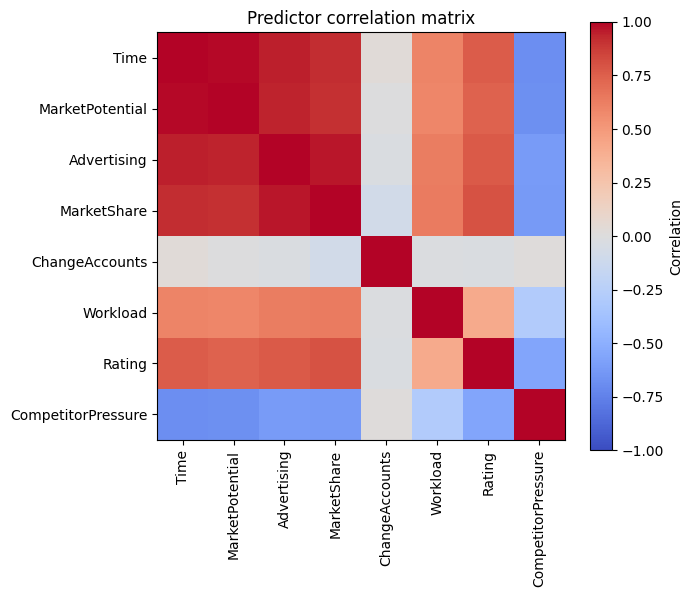

In [3]:
corr = sales[predictors].corr()
plt.figure(figsize=(7, 6))
plt.imshow(corr, vmin=-1, vmax=1, cmap='coolwarm')
plt.colorbar(label='Correlation')
plt.xticks(range(len(predictors)), predictors, rotation=90)
plt.yticks(range(len(predictors)), predictors)
plt.title('Predictor correlation matrix')
plt.tight_layout()

In [4]:
X = sales[predictors].assign(Intercept=1)
X = X[['Intercept'] + predictors]
vif = pd.DataFrame({
    'term': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
})
vif[vif['term'] != 'Intercept'].sort_values('VIF', ascending=False)

,term,VIF
1,Time,73.672439
2,MarketPotential,53.235613
3,Advertising,29.798369
4,MarketShare,21.331880
7,Rating,3.249317
8,CompetitorPressure,2.048255
6,Workload,1.852669
5,ChangeAccounts,1.132978


Interpretation: high VIF is a warning about coefficient interpretation, not necessarily a reason to discard the whole model. Possible responses include collecting more data, combining related predictors, using domain knowledge to keep one of a correlated group, centering polynomial terms, or using a different estimation method such as ridge regression.

In [5]:
full = smf.ols('Sales ~ ' + ' + '.join(predictors), data=sales).fit()
reduced = smf.ols('Sales ~ Time + MarketPotential + Workload + Rating + CompetitorPressure', data=sales).fit()
coef_compare = pd.concat([full.params.rename('full_model'), reduced.params.rename('reduced_model')], axis=1)
coef_compare

,full_model,reduced_model
Intercept,-17539.259597,-18559.555237
Time,-215.128135,-135.012915
MarketPotential,0.429491,0.503249
Advertising,3.821007,NaN
MarketShare,450.951175,NaN
ChangeAccounts,-247.568552,NaN
Workload,-48.777900,41.463656
Rating,215.075502,1104.333459
CompetitorPressure,-95.483494,-71.986026


## Hidden Extrapolation

With multiple predictors, a new point can be inside the min-max range of every individual predictor but still outside the joint data region. The lecture uses leverage to check this:

$$h_0 = x_0'(X'X)^{-1}x_0.$$

Compare $h_0$ with $h_{max}$, the maximum observed leverage $h_{ii}$ from the fitted model. If $h_0 \le h_{max}$, the new point is not flagged by this leverage check. If $h_0 > h_{max}$, treat the prediction as hidden extrapolation.

In [6]:
X_design = full.model.exog
max_hat = full.get_influence().hat_matrix_diag.max()
print(f'Max observed hat value: {max_hat:.4f}')

new_typical = pd.DataFrame({col: [sales[col].median()] for col in predictors})
new_edge = pd.DataFrame({col: [sales[col].median()] for col in predictors})
new_edge['Time'] = sales['Time'].min()
new_edge['MarketPotential'] = sales['MarketPotential'].max()
new_edge['Advertising'] = sales['Advertising'].min()
new_edge['MarketShare'] = sales['MarketShare'].max()

for label, new_df in [('typical', new_typical), ('edge combination', new_edge)]:
    x0 = np.array([[1.0] + [float(new_df[col].iloc[0]) for col in predictors]])
    h0 = float((x0 @ np.linalg.inv(X_design.T @ X_design) @ x0.T)[0, 0])
    print(f'{label:16s} h0={h0:.4f}; hidden extrapolation? {h0 > max_hat}')

Max observed hat value: 0.3942
typical          h0=0.0542; hidden extrapolation? False
edge combination h0=21.1092; hidden extrapolation? True


Transfer question: why is checking each predictor's min and max not enough in multiple regression?